# Queue Processing Graph

## Setup and Configuration

In [6]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

# Import settings
from src.config import settings

print(f"Application: {settings.app_name}")
print(f"Version: {settings.app_version}")
print(f"Default LLM Model: {settings.default_llm_model}")
print(f"Temperature: {settings.default_llm_temperature}")

Application: Data Agent LangGraph
Version: 0.1.0
Default LLM Model: gpt-4o
Temperature: 0.7


## Import Dependencies

In [7]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import numpy as np
from typing import Any, Optional, List

## Init LLM

In [8]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=settings.default_llm_model, 
    temperature=settings.default_llm_temperature,
    api_key=settings.openai_api_key
)

## State Definition

In [9]:
# create custom reducers

from typing import Dict



In [10]:
from typing import Dict
from src.graphs.custom_reducers.reduce_search_payload import reduce_search_payload
from src.graphs.state_definitions.overall_state import SearchPayload
    
class QueueOverallState(TypedDict):
    # reuse channels from main graph
    messages: Annotated[list, add_messages]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload,reduce_search_payload]
        
    # node-specific channels
    map_queues_to_ids: Dict[str,str]
    map_extracted_queue_to_ids: Dict[str,str]
    
class QueueOutputState(TypedDict):
    # reuse channels from main graph
    messages: Annotated[list, add_messages]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload,reduce_search_payload]

## Construct queue mapping node

In [11]:
import requests
import json

def construct_queue_mapping(state: QueueOverallState):
    
    print("💡 I am making graph QL call to fetch queue names and ids")

    url = "https://dash-dev.staple.io/graphql"

    query = """
    query getSelectableQueues {
        queues: getAssignedQueues {
            id
            name
        }
    }
    """

    headers = {
        "Accept": "*/*",
        "Accept-Encoding": "gzip, deflate, br",
        "Content-Type": "application/json",
        "User-Agent": "PostmanRuntime/7.47.1"
    }

    # Full cookie string from Postman
    cookie_string = "__cfduid=1763862616.948.43.883255|92177388de9c0d9ffff64d7c4b776c11; __stripe_mid=b7c69d34-29c8-4cf2-b50e-79da18b1c18af4d1d9; crisp-client%2Fsession%2Fb5af01cf-848b-4812-b6b6-c1ee3aa52ffa=session_25d399fc-8e6f-442c-ae36-28653177ec93; __t__SGDEV=Bearer%20eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJ1aWQiOjEsImlkZW50aXR5IjoiMSIsImlhdCI6MTc2Mzg4ODg3NiwiZXhwIjoxNzYzOTMyMDc2fQ.Itvj4rIJHCFfAuGxmLYrS1DVxBzLXgptD1vkeYWMByA"


    # Add cookie as a header (alternative approach)
    headers["Cookie"] = cookie_string

    payload = {
        "operationName": "getSelectableQueues",
        "query": query,
        "variables": {}
    }

    response = requests.post(
        url,
        json=payload,
        headers=headers
    )

    print(f"Status Code: {response.status_code}")

    mapping_queue_name_ids={}

    if response.status_code == 200:
        data = response.json()
        # print(json.dumps(data, indent=2))
        print("data: ",data)
        
        mapping_queue_name_ids={queue_data["name"]:queue_data["id"] for queue_data in data['data']['queues']}

    else:
        print(f"Error: {response.text}")
        
    print("mapping_queue_name_ids: ",mapping_queue_name_ids)
    
    return {"map_queues_to_ids":mapping_queue_name_ids}

## Extract queues name from search query node

In [12]:
from pydantic import BaseModel, Field
from src.graphs.prompts.extract_queues_from_search_query import QUEUES_NAME_EXTRACTION_FROM_QUERY_PROMPT

class ExtractedQueueNames(BaseModel):
    """Extracted queue names from user query"""
    matched_extracted_queue_names: List[str] = Field(
        default_factory=list,  # Add default empty list
        description="List of all extracted queues"
    )
    reasoning: str = Field(
        description="Brief explanation of which queue names were identified")


def extract_queue_names_node(state: QueueOverallState) -> dict:
    """Extract queue names from user query"""
    
    print("\n 🚀 I am in extracting queue names from query")
    
    structured_llm = llm.with_structured_output(
        ExtractedQueueNames
    )
    
    system_message =  QUEUES_NAME_EXTRACTION_FROM_QUERY_PROMPT.format(
        queue_names=list(state["map_queues_to_ids"].keys())
    )
    
    messages = [SystemMessage(content=system_message)] + state["messages"]
    
    result: ExtractedQueueNames = structured_llm.invoke(messages)
    
    print(f"   Extracted queue names: {result.matched_extracted_queue_names}")
    print(f"   Reasoning: {result.reasoning}")
    
    map_extracted_queue_to_ids={}
    
    if not result.matched_extracted_queue_names:
        print("   No queue names found in query")
    else:
        queue_count = len(result.matched_extracted_queue_names)
        queue_list = ', '.join(result.matched_extracted_queue_names)
        print(f"   Found {queue_count} queue(s): {queue_list}")
        
        map_extracted_queue_to_ids={extracted_queue_name: state['map_queues_to_ids'].get(extracted_queue_name,None) for extracted_queue_name in result.matched_extracted_queue_names}
    
    return {
        "map_extracted_queue_to_ids": map_extracted_queue_to_ids,
        "messages": [AIMessage(content=result.reasoning)],
    }

## User refine search query node

In [13]:
def user_refine_search_query(state: QueueOverallState):
    return {}

## Update Search Payload Node

In [14]:
def update_search_payload(state: QueueOverallState):
    
    print("🚀 I am in update_search_payload node")
    
    map_extracted_queue_to_ids=state['map_extracted_queue_to_ids']
    search_attributes=state['search_attributes']
    
    updated_search_attributes=[attr for attr in search_attributes if attr != "queue"]
    
    return {"search_payload":{
                "queues":map_extracted_queue_to_ids
            },
            "search_attributes": updated_search_attributes
            }

## Queue processing router

In [15]:
def routing_queue_processing(state: QueueOverallState):
    
    map_extracted_queue_to_ids=state['map_extracted_queue_to_ids']
    
    if not map_extracted_queue_to_ids or not all(list(map_extracted_queue_to_ids.values())):
        return "no queues extracted - user to refine query"
    
    
    return "correct queues extracted - update search payload"

## Build Graph

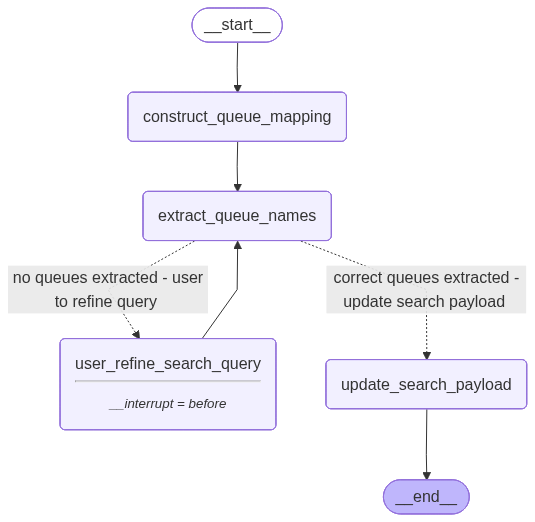

In [16]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

queue_builder=StateGraph(state_schema=QueueOverallState)

# add node
queue_builder.add_node("construct_queue_mapping",construct_queue_mapping)
queue_builder.add_node("extract_queue_names",extract_queue_names_node)
queue_builder.add_node("user_refine_search_query",user_refine_search_query)
queue_builder.add_node("update_search_payload",update_search_payload)

# add edges
queue_builder.add_edge(START,"construct_queue_mapping")
queue_builder.add_edge("construct_queue_mapping","extract_queue_names")

queue_builder.add_conditional_edges("extract_queue_names", 
                                   routing_queue_processing, 
                                   {"no queues extracted - user to refine query":"user_refine_search_query",
                                    "correct queues extracted - update search payload":"update_search_payload"})
queue_builder.add_edge("user_refine_search_query","extract_queue_names")
queue_builder.add_edge("update_search_payload",END)


# Compile
memory = MemorySaver()
graph = queue_builder.compile(interrupt_before=["user_refine_search_query"],checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [17]:
thread = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [HumanMessage(content="Search all documents in queues containing Louis")],"search_attributes":["queue"]},thread)

💡 I am making graph QL call to fetch queue names and ids
Status Code: 200
data:  {'data': {'queues': [{'id': 1213, 'name': '...'}, {'id': 2321, 'name': '001'}, {'id': 3049, 'name': '101'}, {'id': 2313, 'name': '101'}, {'id': 2284, 'name': '101'}, {'id': 2317, 'name': '101'}, {'id': 3108, 'name': '1017 test queue'}, {'id': 3050, 'name': '102'}, {'id': 3051, 'name': '103'}, {'id': 2476, 'name': '1084'}, {'id': 4228, 'name': '10Nov25'}, {'id': 2722, 'name': '1171 '}, {'id': 4236, 'name': '11Nov25'}, {'id': 2974, 'name': '1334_1'}, {'id': 3917, 'name': '1343'}, {'id': 4259, 'name': '17Nov25'}, {'id': 4260, 'name': '17nov25P2'}, {'id': 4261, 'name': '17nov25p3'}, {'id': 4262, 'name': '17nov25p4'}, {'id': 2319, 'name': '201'}, {'id': 2320, 'name': '202'}, {'id': 4117, 'name': '2025Invoice'}, {'id': 2517, 'name': '209'}, {'id': 2526, 'name': '210'}, {'id': 4000, 'name': '210825'}, {'id': 4001, 'name': '210825 2'}, {'id': 4002, 'name': '210825 3'}, {'id': 4004, 'name': '210825 4'}, {'id': 2664

{'messages': [HumanMessage(content='Search all documents in queues containing Louis', additional_kwargs={}, response_metadata={}, id='8a254faf-4a00-4d68-a181-3ffa0f5ec20f'),
  AIMessage(content="The user's query mentions queues containing 'Louis'. By matching with the available queues, the queue 'louis-test-1' matches the criteria.", additional_kwargs={}, response_metadata={}, id='4ff9123a-ccd4-4517-9bad-ed897c9cdbb7')],
 'search_attributes': [],
 'search_payload': {'queues': {'louis-test-1': 4052}},
 'map_queues_to_ids': {'...': 1213,
  '001': 2321,
  '101': 2317,
  '1017 test queue': 3108,
  '102': 3050,
  '103': 3051,
  '1084': 2476,
  '10Nov25': 4228,
  '1171 ': 2722,
  '11Nov25': 4236,
  '1334_1': 2974,
  '1343': 3917,
  '17Nov25': 4259,
  '17nov25P2': 4260,
  '17nov25p3': 4261,
  '17nov25p4': 4262,
  '201': 2319,
  '202': 2320,
  '2025Invoice': 4117,
  '209': 2517,
  '210': 2526,
  '210825': 4000,
  '210825 2': 4001,
  '210825 3': 4002,
  '210825 4': 4004,
  '238': 2665,
  '244 N

In [18]:
thread = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [HumanMessage(content="Search all documents in queues kaka")],"search_attributes":["queue"]},thread)

💡 I am making graph QL call to fetch queue names and ids
Status Code: 200
data:  {'data': {'queues': [{'id': 1213, 'name': '...'}, {'id': 2321, 'name': '001'}, {'id': 3049, 'name': '101'}, {'id': 2313, 'name': '101'}, {'id': 2284, 'name': '101'}, {'id': 2317, 'name': '101'}, {'id': 3108, 'name': '1017 test queue'}, {'id': 3050, 'name': '102'}, {'id': 3051, 'name': '103'}, {'id': 2476, 'name': '1084'}, {'id': 4228, 'name': '10Nov25'}, {'id': 2722, 'name': '1171 '}, {'id': 4236, 'name': '11Nov25'}, {'id': 2974, 'name': '1334_1'}, {'id': 3917, 'name': '1343'}, {'id': 4259, 'name': '17Nov25'}, {'id': 4260, 'name': '17nov25P2'}, {'id': 4261, 'name': '17nov25p3'}, {'id': 4262, 'name': '17nov25p4'}, {'id': 2319, 'name': '201'}, {'id': 2320, 'name': '202'}, {'id': 4117, 'name': '2025Invoice'}, {'id': 2517, 'name': '209'}, {'id': 2526, 'name': '210'}, {'id': 4000, 'name': '210825'}, {'id': 4001, 'name': '210825 2'}, {'id': 4002, 'name': '210825 3'}, {'id': 4004, 'name': '210825 4'}, {'id': 2664

{'messages': [HumanMessage(content='Search all documents in queues containing Louis', additional_kwargs={}, response_metadata={}, id='8a254faf-4a00-4d68-a181-3ffa0f5ec20f'),
  AIMessage(content="The user's query mentions queues containing 'Louis'. By matching with the available queues, the queue 'louis-test-1' matches the criteria.", additional_kwargs={}, response_metadata={}, id='4ff9123a-ccd4-4517-9bad-ed897c9cdbb7'),
  HumanMessage(content='Search all documents in queues kaka', additional_kwargs={}, response_metadata={}, id='562c4b80-afd0-410f-9f74-2d5aa3cd7f4a'),
  AIMessage(content="The user's query mentioned 'kaka', but there are no available queues matching or partially matching 'kaka'.", additional_kwargs={}, response_metadata={}, id='5dde7fd4-861c-49d9-a392-59f1b7221936')],
 'search_attributes': ['queue'],
 'search_payload': {'queues': {'louis-test-1': 4052}},
 'map_queues_to_ids': {'...': 1213,
  '001': 2321,
  '101': 2317,
  '1017 test queue': 3108,
  '102': 3050,
  '103': 3

In [19]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Search all documents in queues containing Louis', additional_kwargs={}, response_metadata={}, id='8a254faf-4a00-4d68-a181-3ffa0f5ec20f'), AIMessage(content="The user's query mentions queues containing 'Louis'. By matching with the available queues, the queue 'louis-test-1' matches the criteria.", additional_kwargs={}, response_metadata={}, id='4ff9123a-ccd4-4517-9bad-ed897c9cdbb7'), HumanMessage(content='Search all documents in queues kaka', additional_kwargs={}, response_metadata={}, id='562c4b80-afd0-410f-9f74-2d5aa3cd7f4a'), AIMessage(content="The user's query mentioned 'kaka', but there are no available queues matching or partially matching 'kaka'.", additional_kwargs={}, response_metadata={}, id='5dde7fd4-861c-49d9-a392-59f1b7221936')], 'search_attributes': ['queue'], 'search_payload': {'queues': {'louis-test-1': 4052}}, 'map_queues_to_ids': {'...': 1213, '001': 2321, '101': 2317, '1017 test queue': 3108, '102': 3050, '103':

In [20]:
state.next

('user_refine_search_query',)

In [21]:
graph.update_state(
    thread,
    {"messages":[HumanMessage(content="Sorry, actually I want to search all documents in queue containing Louis")]}
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0c84f0-47e7-6abc-8008-403a3e965c91'}}

In [22]:
graph.invoke(None,thread)


 🚀 I am in extracting queue names from query
   Extracted queue names: ['louis-test-1']
   Reasoning: The user's query specifies searching for queues containing 'Louis'. The available queue 'louis-test-1' matches this criteria.
   Found 1 queue(s): louis-test-1
🚀 I am in update_search_payload node


{'messages': [HumanMessage(content='Search all documents in queues containing Louis', additional_kwargs={}, response_metadata={}, id='8a254faf-4a00-4d68-a181-3ffa0f5ec20f'),
  AIMessage(content="The user's query mentions queues containing 'Louis'. By matching with the available queues, the queue 'louis-test-1' matches the criteria.", additional_kwargs={}, response_metadata={}, id='4ff9123a-ccd4-4517-9bad-ed897c9cdbb7'),
  HumanMessage(content='Search all documents in queues kaka', additional_kwargs={}, response_metadata={}, id='562c4b80-afd0-410f-9f74-2d5aa3cd7f4a'),
  AIMessage(content="The user's query mentioned 'kaka', but there are no available queues matching or partially matching 'kaka'.", additional_kwargs={}, response_metadata={}, id='5dde7fd4-861c-49d9-a392-59f1b7221936'),
  HumanMessage(content='Sorry, actually I want to search all documents in queue containing Louis', additional_kwargs={}, response_metadata={}, id='199f8632-ebb0-4b69-9e6e-155ed36beca7'),
  AIMessage(content=